In [9]:
files = !ls ./ | grep json | grep eval | grep 2025
for file in files:
    print('"{}",'.format(file))

"eval_20250104-145818_data_model_config.json",
"eval_20250104-145836_data_model_config.json",


将上面的文档名写入`eval_config.json`的result_json_list, 然后运行`eval_csv.py`

In [10]:
! python eval_csv.py

Result save success: ./20250104-150316_result.csv
Eval_config update success: eval_config.json


In [11]:
import pandas as pd

result = pd.read_csv('./20250104-150316_result.csv')
result

,key,data_name,model_name,model_config,exe_name
0,value,data,model,config,eval_20250104-145818_data_model_config.json
1,value,data,model,config,eval_20250104-145836_data_model_config.json


# Visualize

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
result = pd.read_csv('result.csv')
result

,data,model,eval1,eval2
0,data1,model1,9.2,2
1,data1,model2,10.0,1
2,data1,model3,4.2,2
3,data2,model1,9.1,2
4,data2,model2,10.4,1
5,data2,model3,4.7,2
6,data3,model1,9.9,2
7,data3,model2,10.0,1
8,data3,model3,4.2,2


In [3]:
def draw_bar(result, metric):
    analyze = {}
    for table_name in result['data'].unique():
        analyze[table_name] = {}
        for model_name in result['model'].unique():
            analyze[table_name][model_name] = result[(result['data'] == table_name) & (result['model'] == model_name)][metric].item()
    label_list = list(result['data'].unique())
    x = np.arange(0,len(label_list)*len(result['model'].unique()), len(result['model'].unique()))
    width=0.5
    x1 = x - width
    x2 = x 
    x3 = x + width
    y1 = [analyze[table_name]['model1'] for table_name in label_list]
    y2 = [analyze[table_name]['model2'] for table_name in label_list]
    y3 = [analyze[table_name]['model3'] for table_name in label_list]

    plt.figure(figsize=(10,5))
    plt.bar(x1,y1,width=width,label='model1',color='#f9766e',edgecolor='k',zorder=2, hatch='.')
    plt.bar(x2,y2,width=width,label='model2',color='#00bfc4',edgecolor='k',zorder=2, hatch='/')
    plt.bar(x3,y3,width=width,label='model3',color='#fff033',edgecolor='k',zorder=2, hatch='-')
    plt.xticks(x,label_list,fontsize=13, fontweight='bold')

    plt.xlabel('Dataset', fontsize=15, fontweight='bold')
    plt.ylabel('Eval 1', fontsize=15, fontweight='bold')
    legend = plt.legend(loc=1)
    for i in range(len(legend.texts)):
        legend.texts[i].set_weight('bold')
    plt.grid(ls='--',alpha=0.8)

    title = 'Eval 1 on Dataset'
    plt.title(title, fontsize=15, fontweight='bold')
    plt.savefig('{}.pdf'.format(title))
    plt.show()


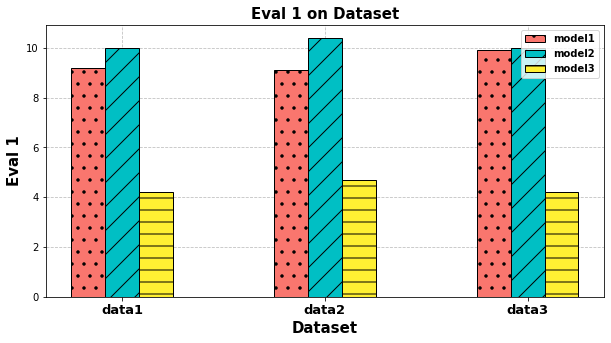

In [4]:
draw_bar(result=result, metric='eval1')

In [5]:
result = pd.read_csv('result2.csv')
result

,data,model,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0,data1,model1,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
1,data1,model2,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1
2,data1,model3,2.0,4.0,6.0,8.0,10.0,12.0,14.0,16.0,18.0,20.0


In [21]:
def draw_plot(result, data_name):
    analyze = {}
    analyze[data_name] = {}
    for model_name in result['model'].unique():
        analyze[data_name][model_name] = []
        for epsilon in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
            analyze[data_name][model_name].append(result[(result['data'] == data_name) & (result['model'] == model_name)][str(epsilon)].item())

    plt.figure(figsize=(7,5))
    epsilon_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    plt.plot(epsilon_list, analyze[data_name]['model1'], 'gs--', label='dptddpm')
    plt.plot(epsilon_list, analyze[data_name]['model2'], 'ys--', label='dpspn')
    plt.plot(epsilon_list, analyze[data_name]['model3'], 'rs--', label='privebayes')
    legend = plt.legend(loc=1)
    for i in range(len(legend.texts)):
        legend.texts[i].set_weight('bold')
    plt.grid(ls='--',alpha=0.8)

    plt.xticks(epsilon_list, fontsize=13, fontweight='bold')
    plt.xlabel('Epsilon', fontsize=15, fontweight='bold')
    plt.ylabel('Corr.Diff Mean', fontsize=15, fontweight='bold')
    title = 'Effect of Privacy on Corr.Diff Mean ({})'.format(data_name)
    plt.title(title, fontsize=15, fontweight='bold' )
    plt.savefig('{}.pdf'.format(title))

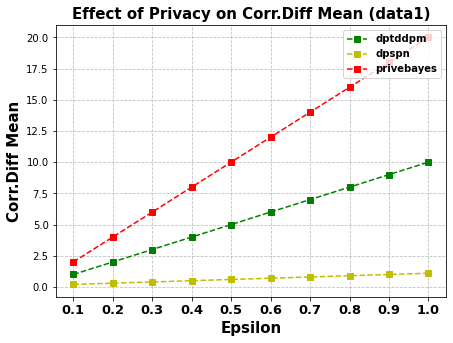

In [22]:
draw_plot(result, 'data1')